# Compute Derivative and laplacian

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline , make_interp_spline

In [71]:
def f(x,order):
    order = int(order)
    if order == 0:
        return np.exp(-np.power(x,2))
    elif order == 1:
        return -2*x*f(x,0)
    elif order == 2:
        return -2*f(x,0) + 4*np.power(x,2)*f(x,0)
    else:
        print("Invalid order!")
        return np.zeros(len(x),dtype=float)    

def g(x,order):
    order = int(order)
    if order == 0:
        return np.exp(-np.power(x,2))*np.sin(x)
    elif order == 1:
        return np.exp(-np.power(x,2))*(np.cos(x) - 2*x*np.sin(x))
    elif order == 2:
        return np.exp(-np.power(x,2))*(-4*x*np.cos(x)+(-3+4*np.power(x,2))*np.sin(x))
    else:
        print("Invalid order!")
        return np.zeros(len(x),dtype=float)  

def A(x,order):
    order = int(order)
    if order == 0:
        return np.exp(-np.power(x,2))*np.cos(x)
    elif order == 1:
        return -np.exp(-np.power(x,2))*(2*x*np.cos(x) + np.sin(x))
    elif order == 2:
        return np.exp(-np.power(x,2))*((4*np.power(x,2)-3)*np.cos(x)+4*x*np.sin(x))
    else:
        print("Invalid order!")
        return np.zeros(len(x),dtype=float)  

def R(x,order):
    order = int(order)
    if order == 0:
        return np.exp(np.cos(x))
    elif order == 1:
        return -R(x,0)*np.sin(x)
    elif order == 2:
        return R(x,0)*(-np.cos(x) + np.power(np.sin(x),2))
    else:
        print("Invalid order!")
        return np.zeros(len(x),dtype=float)  

In [72]:
eta = 0.0

def laplacian_numpy(func,x):
    """ compute first and second derivatives """
    first = np.gradient(func,x,edge_order=2)
    second = np.gradient(first,x,edge_order=2)
    first[0] = 0.0
    """ apply boundary conditions """
    return second + first/(x+eta)

def analytical(x,func):
    if func == "f":
        return 4*f(x,0)*(np.power(x,2) - 1)
    elif func == "g":
        c1 = np.cos(x)/x * (1-4*np.power(x,2))
        c2 = np.sin(x)*(4*np.power(x,2)-5)
        return np.exp(-np.power(x,2))*(c1+c2)
    elif func == "A":
        c1 = np.cos(x) * (-5+4*np.power(x,2))
        c2 = np.sin(x)/x *(4*np.power(x,2)-1)
        return np.exp(-np.power(x,2))*(c1+c2)
    elif func == "R":
        c1 = np.cos(x) + np.sin(x)/x - np.power(np.sin(x),2)
        return -R(x,0)*c1
    else:
        print("Invalid function!!")
        return x*0.0


""" compute derivative """

# without extrapolation
def derivative_rui(func,x,order,extrapolate,k):
    order = int(order)
    # compute step
    step = x[1] - x[0]
    # pad array
    Npad = 2
    pad = np.pad(func,(Npad,Npad), mode='constant' , constant_values = (func[0],func[-1]))
    N = len(func)
    # compute derivative 1st order
    if order == 1:
        # 5-point derivative
        first = (pad[Npad-2:Npad+N-2] - 8*pad[Npad-1:Npad+N-1] + 8*pad[Npad+1:Npad+N+1] - pad[Npad+2:Npad+N+2])/12
        if extrapolate:
            first = first/step
            first = extrapolate_derivative(x,first,k)
            return first
        else:
            # compute edges using second order approximation
            first[0] = -3/2*func[0] + 2*func[1] - 0.5*func[2]
            first[-1] = 3/2*func[-1] - 2*func[-2] + 0.5*func[-3]
            # compute near-edge using 3-point derivative
            first[1] = (func[2] - func[0])/2
            first[-2] = (func[-1] - func[-3])/2
            return first/step
    # compute second order derivative
    elif order == 2:
        # 5-point derivative
        second = (-pad[Npad-2:Npad+N-2] + 16*pad[Npad-1:Npad+N-1] - 30*pad[Npad:Npad+N] + 16*pad[Npad+1:Npad+N+1] - pad[Npad+2:Npad+N+2])/12
        if extrapolate:
            second = second/step**2
            second = extrapolate_derivative(x,second,k)
            return second
        else:
            # compute edges using 2-order approximation
            second[0] = 0.5*func[2] - func[1] + 0.5*func[0]
            second[-1] = 0.5*func[-1] - func[-2] + 0.5*func[-3]
            # compute near-edge using 3-point derivative
            second[1] = func[2] - 2*func[1] + func[0]
            second[-2] = func[-1] - 2*func[-2] + func[-3]
            return second/step**2
    else:
        print("Invalid order!")
        return np.zeros(len(x),dtype=float)   

def extrapolate_derivative(x,derivative,k):
    N = len(derivative)

    spline = make_interp_spline(x[2:N-2], derivative[2:N-2],k = k)

    derivative[0:2] = spline(x[0:2])
    derivative[N-2:N] = spline(x[N-2:N])

    return derivative


def laplacian_rui(func,x):

    """ compute first derivative """
    first = derivative_rui(func,x,1,False,9)

    """ compute second derivative """
    second = derivative_rui(func,x,2,False,9)

    """ compute laplacian """
    laplacian = second + first/x

    """ extrapolate edges """
    laplacian = extrapolate_derivative(x,laplacian,9)

    return laplacian
    
    

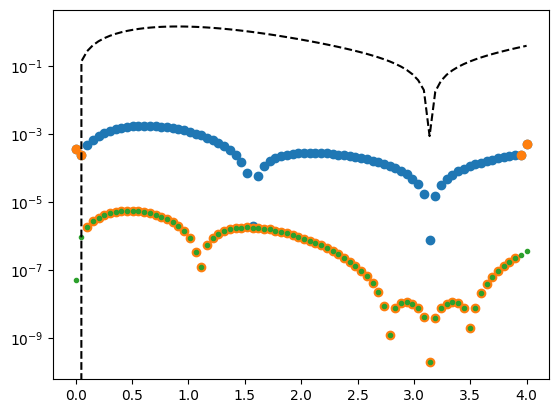

In [73]:
x = np.linspace(0.0,4,80)
func = R(x,0)
z = R(x,1)

y = derivative_rui(func,x,1,False,9)
test = derivative_rui(func,x,1,True,9)

LN = np.gradient(func,x,edge_order=2)
plt.scatter(x,np.abs((LN-z)))
plt.scatter(x,np.abs((y-z)))
plt.scatter(x,np.abs((test-z)),marker = ".")
plt.plot(x,np.abs((z)),color = "black" , ls = "dashed")
plt.yscale("log")
plt.show()

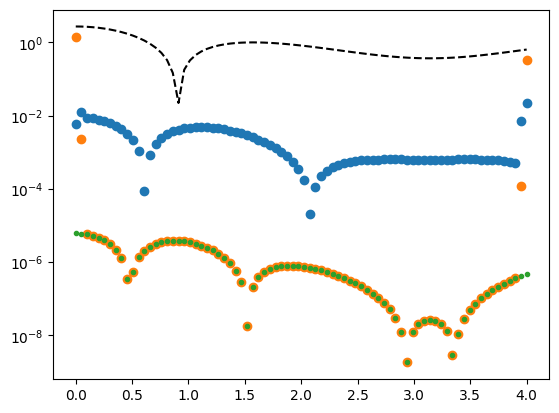

In [74]:
x = np.linspace(0.0,4,80)
func = R(x,0)
z = R(x,2)

y = derivative_rui(func,x,2,False,9)
test = derivative_rui(func,x,2,True,9)

LN = np.gradient(np.gradient(func,x,edge_order=2),x,edge_order=2)
plt.scatter(x,np.abs((LN-z)))
plt.scatter(x,np.abs((y-z)))
plt.scatter(x,np.abs((test-z)),marker = ".")
plt.plot(x,np.abs((z)),color = "black" , ls = "dashed")
plt.yscale("log")
plt.show()

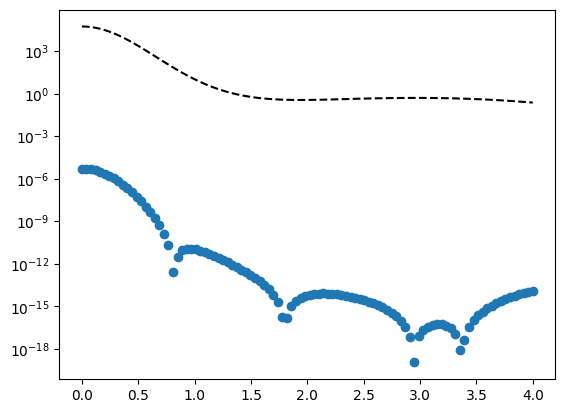

In [79]:
x = np.linspace(1e-10,4,100)
func = R(x,0)
z = np.exp(-analytical(x,"R"))

y = np.exp(-laplacian_rui(func,x))

plt.scatter(x,np.power(y-z,2))
plt.plot(x,np.power(z,2),color = "black" , ls = "dashed")
plt.yscale("log")
plt.show()

# Solve radial equation

## Approach 1

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import bec2DCylindrical.utils as ut
from scipy.integrate import simpson

In [3]:
def potential(x):
    return 0.5*np.power(x,2)

def Hamiltonian(func,x):
    x = np.real(x)
    N = ComputeNorm(func,x)
    func = func/np.sqrt(N)
    # return kinetic propagator
    kinetic = -0.5*ut.laplacian(func,x)
    # compute potential propagator
    pot = potential(x)*func
    return kinetic + pot

def ComputeNorm(func,x):
    N = x*func*np.conjugate(func)
    return 2*np.pi*simpson(N,np.real(x))

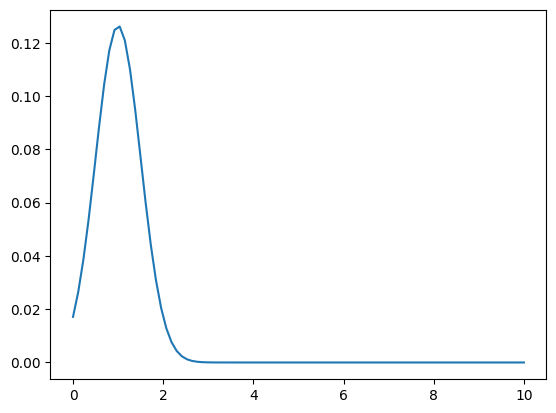

In [50]:
r = np.linspace(1e-10,10,88)
psi0 = np.exp(-np.power(r-1,2)) + 1j*0
psi0 = psi0/np.sqrt(ComputeNorm(np.copy(psi0),r))
plt.plot(np.real(r),np.real(psi0*np.conjugate(psi0)))
plt.show()

In [51]:
def harmonic(x):
    # compute norm factor
    norm = 1/np.sqrt(np.pi)
    phi = norm*np.exp(-np.power(x,2)/2)
    return phi

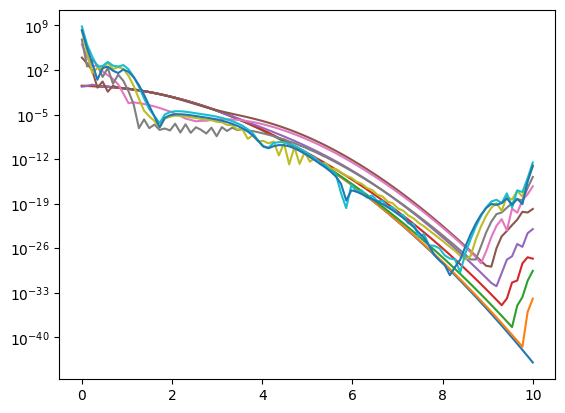

In [52]:
func = harmonic(r)
H = func
plt.plot(r,np.abs(func)**2)
for i in range(0,10):
    H = Hamiltonian(H,r)
    plt.plot(r,np.abs(H)**2)
plt.yscale("log")

In [13]:
iterations = 30000
step = 0.001
norms = []

ground = harmonic(r)
psi = np.copy(psi0)
for i in range(0,iterations):
    # Runge-kutta 3-th order
    k0 = -step*Hamiltonian(psi,r)
    k1 = -step*Hamiltonian(psi+k0/2,r)
    k2 = -step*Hamiltonian(psi+2*k1-k0,r)

    psi = psi + (k0 + 4*k1 + k2)/6

    # normalize psi
    psi = psi/np.sqrt(ComputeNorm(np.copy(psi),r))

    if i%100:
        norms.append(np.power(np.abs(psi-ground),2).sum())


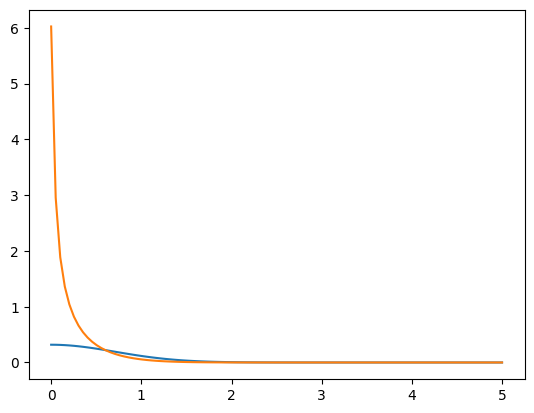

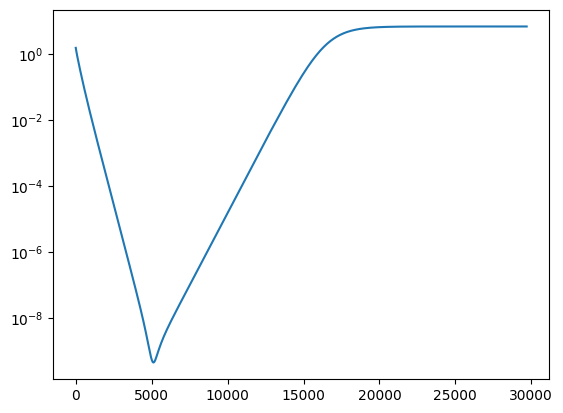

In [14]:
plt.plot(r,ground*np.conjugate(ground))
plt.plot(r,psi*np.conjugate(psi))
plt.show()

plt.plot(norms)
plt.yscale("log")
plt.show()

## Aproach 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import bec2DCylindrical.utils as ut
from scipy.integrate import simpson

In [ ]:
def potential(x):
    return 0.5*np.power(x,2)

def laplacian(func,x):
    """ compute second derivative """
    second = ut.derivative_rui(func,x,2,False,9)

    """ compute laplacian """
    lap = second

    """ extrapolate edges """
    #lap = ut.extrapolate_derivative(x,lap,9)

    return lap

def Hamiltonian(func,x):
    x = np.real(x)
    # normalize func
    func = func/np.sqrt(ComputeNorm(np.copy(func),x))
    # return kinetic propagator
    kinetic = -0.5*laplacian(func,x)*np.exp(2*x)
    # compute potential propagator
    r = np.exp(-x)
    pot = potential(r)*func
    return kinetic + pot

def ComputeNorm(func,x):
    N = -np.exp(-2*np.real(x))*func*np.conjugate(func)
    return np.real(-2*np.pi*simpson(N,np.real(x)))

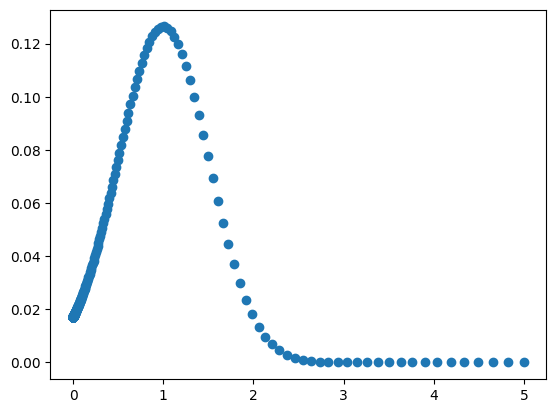

In [156]:
rmin = 1e-7
rmax = 5.0
y = np.linspace(-np.log(rmax),-np.log(rmin),500)
r = np.exp(-y)
psi0 = np.exp(-np.power(r-1,2)) + 1j*0
psi0 = psi0/np.sqrt(ComputeNorm(np.copy(psi0),y))
plt.scatter(np.real(r),np.real(psi0*np.conjugate(psi0)))
plt.show()

In [157]:
def harmonic(x):
    # compute norm factor
    norm = 1/np.sqrt(np.pi)
    phi = norm*np.exp(-np.power(x,2)/2)
    return phi + 1j*0

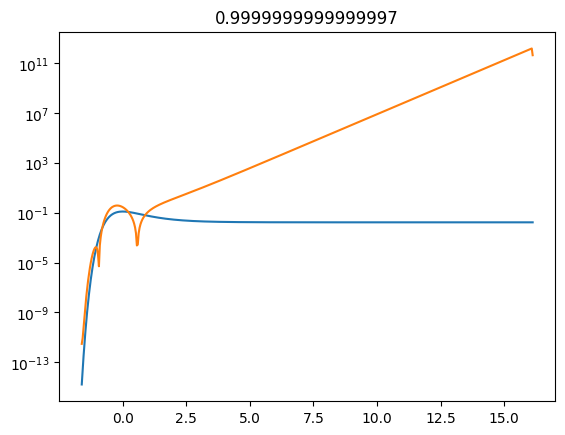

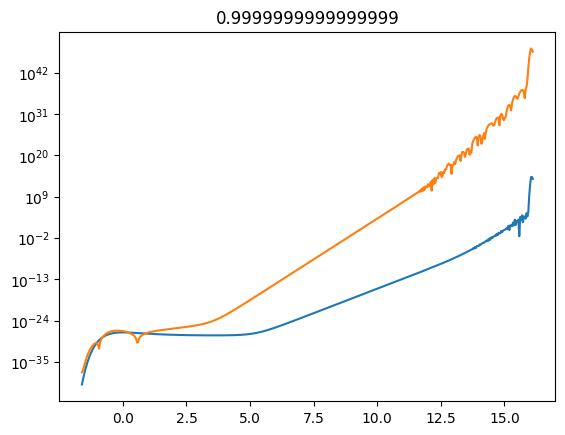

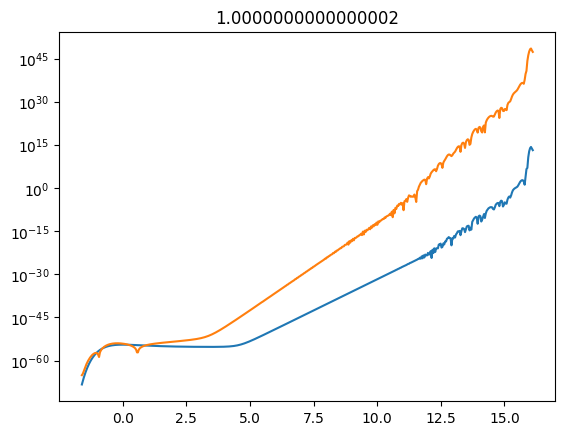

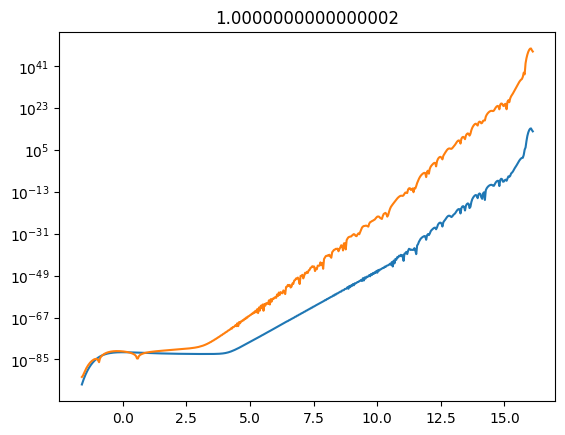

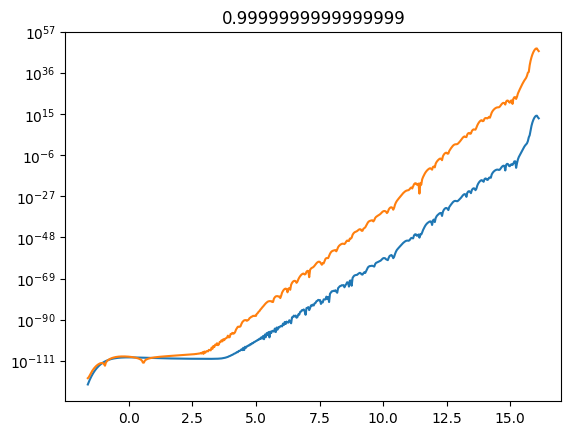

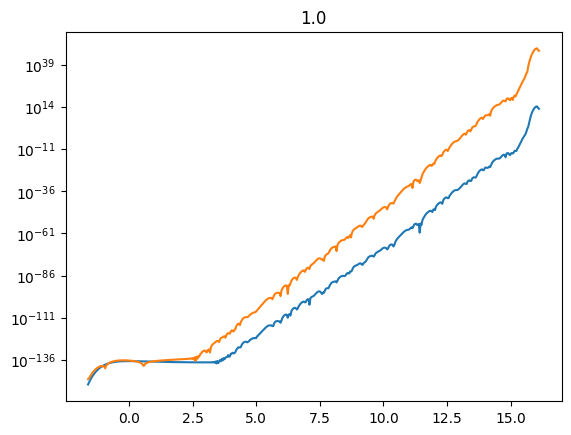

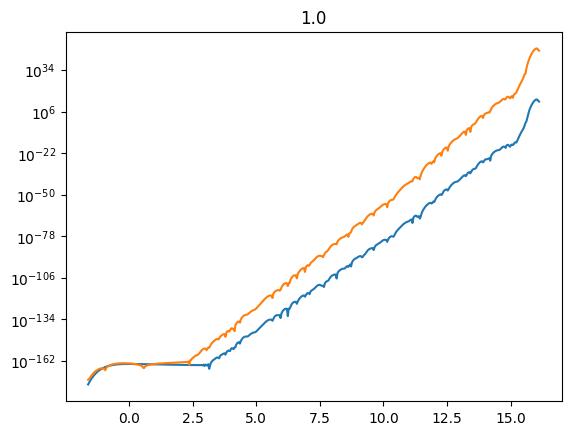

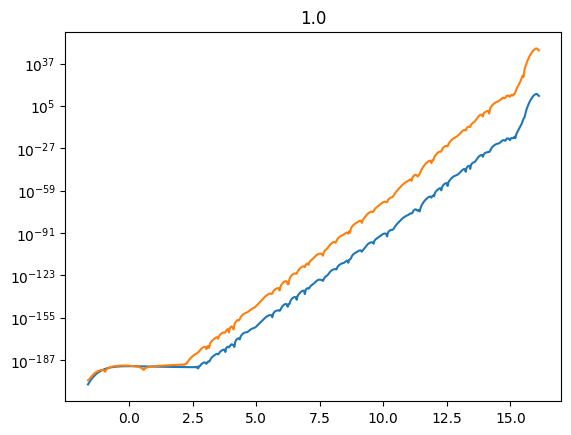

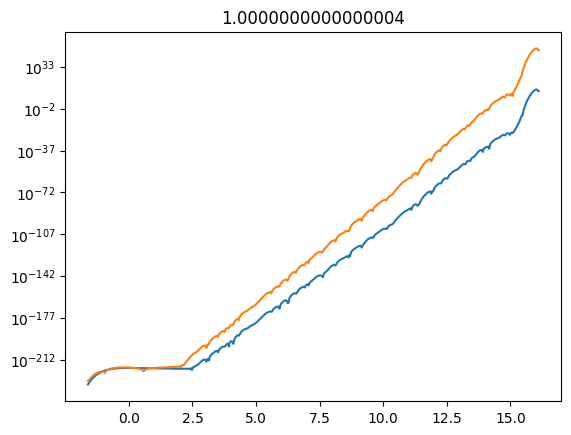

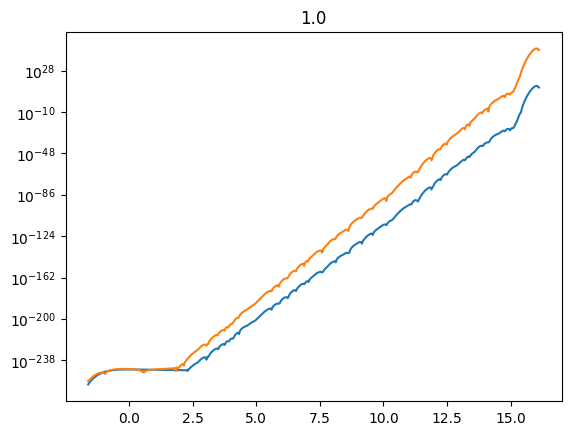

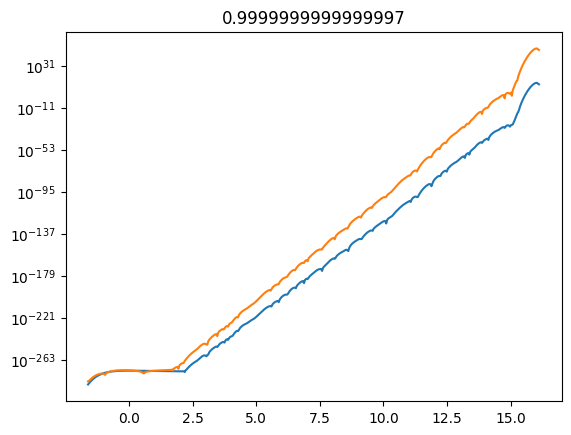

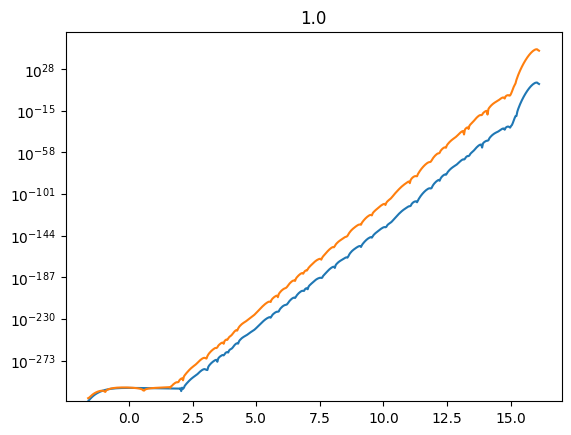

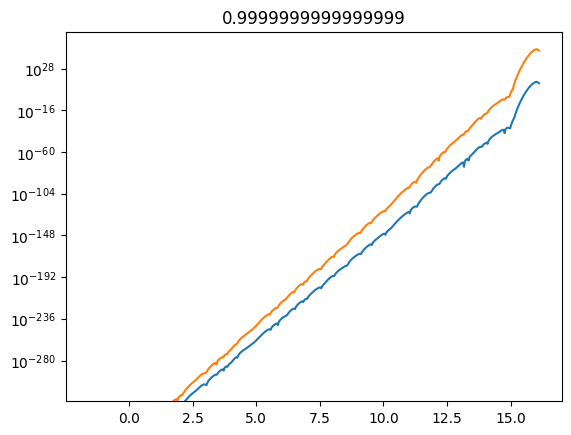

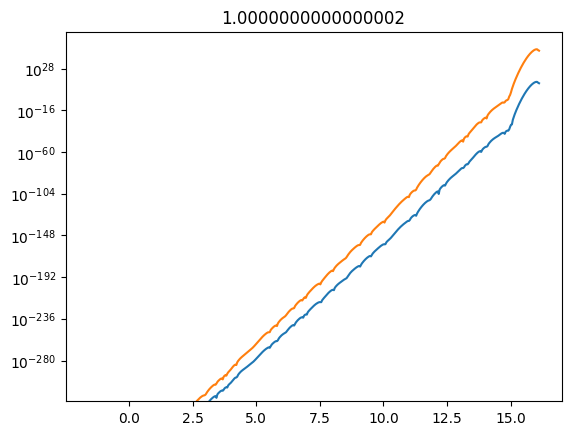

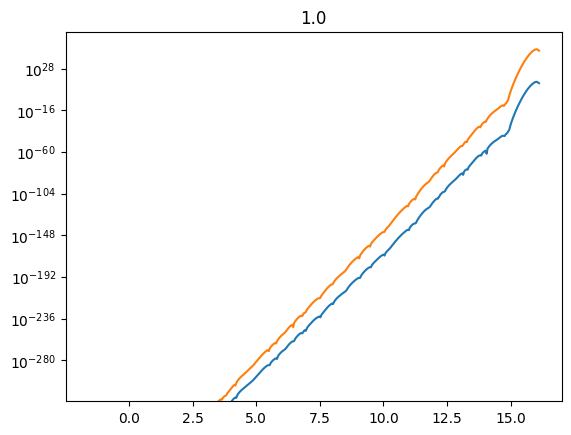

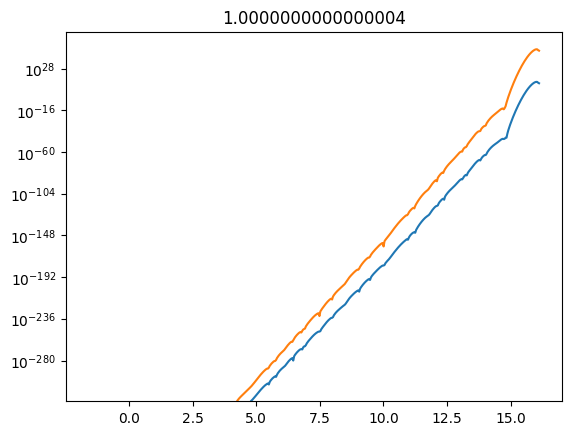

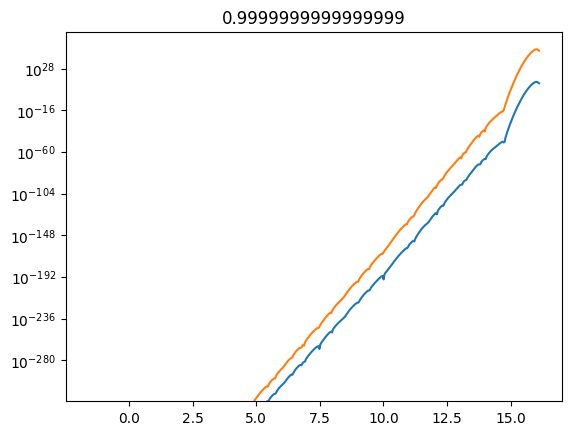

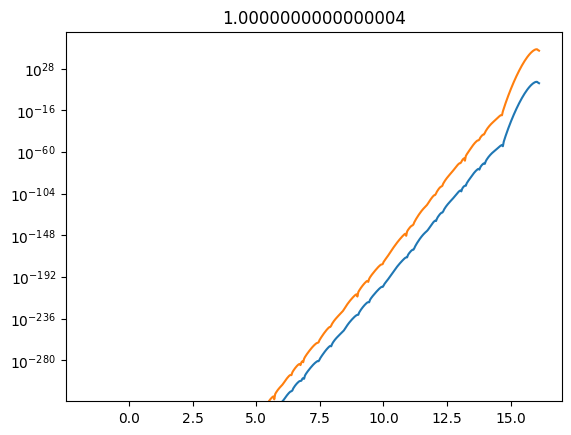

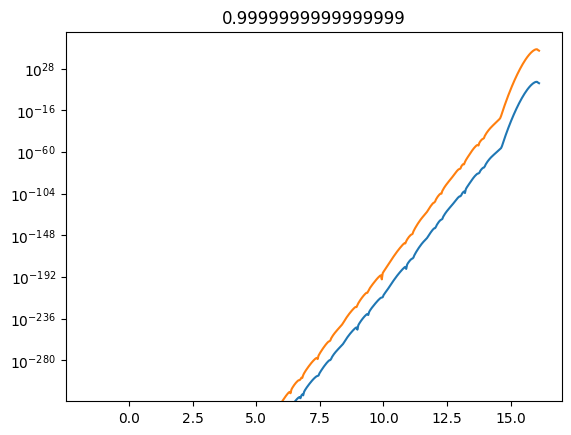

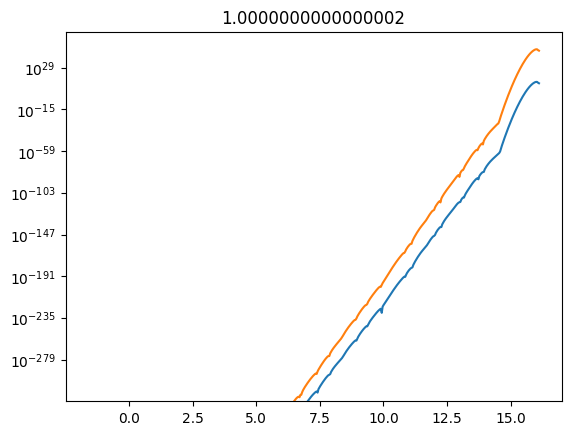

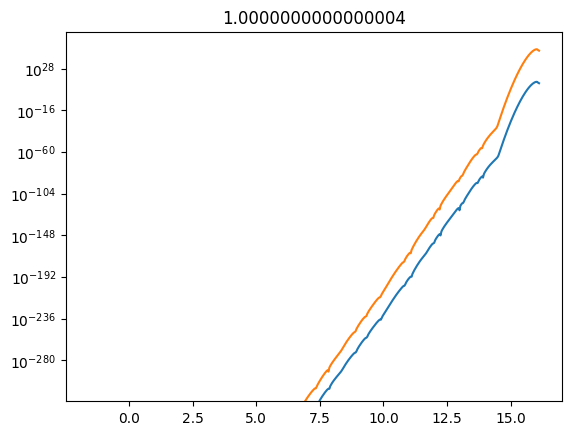

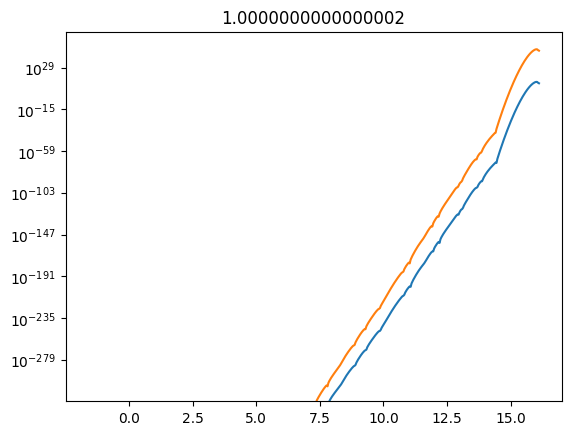

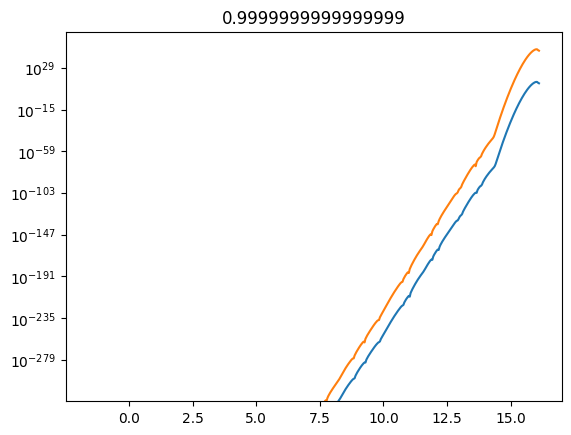

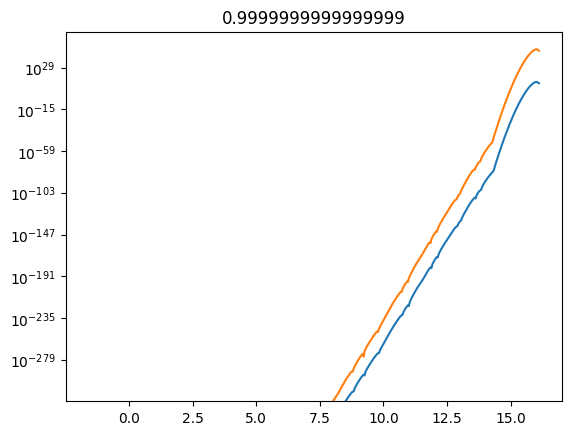

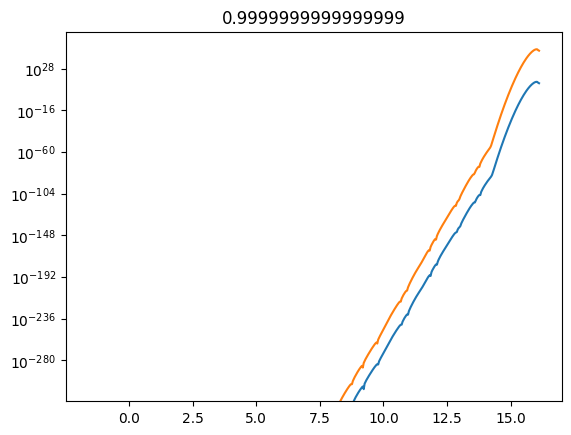

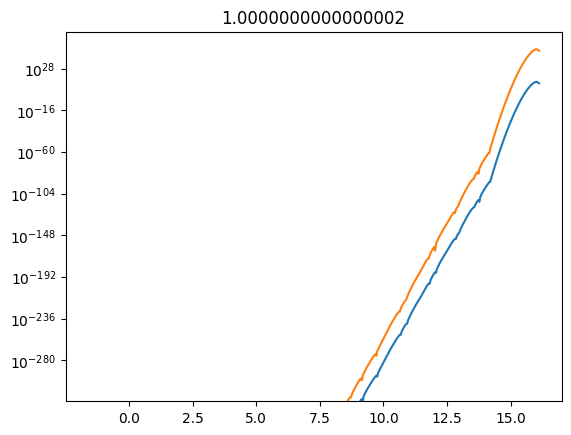

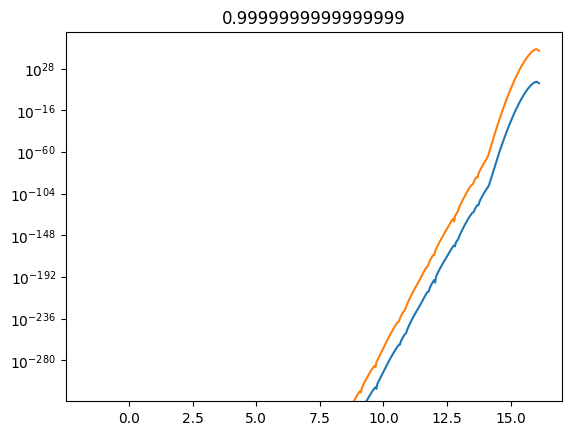

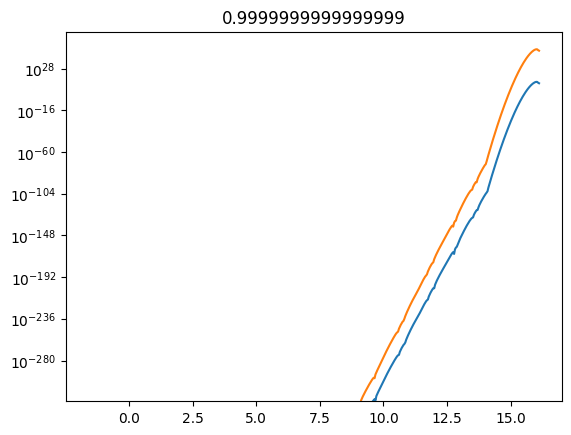

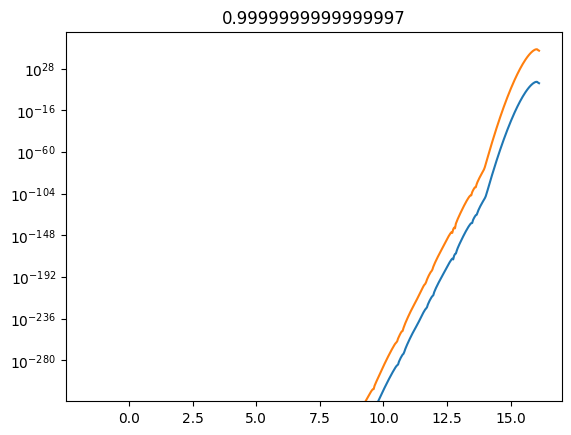

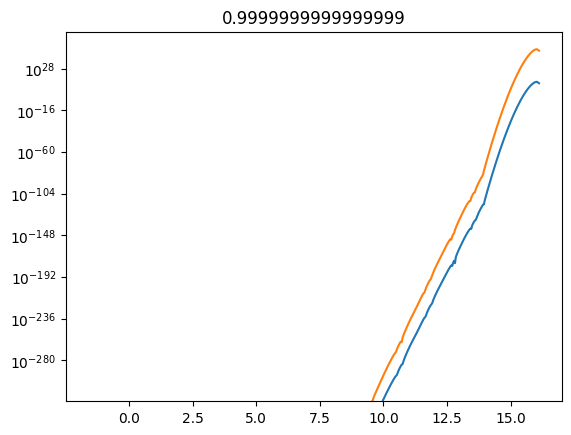

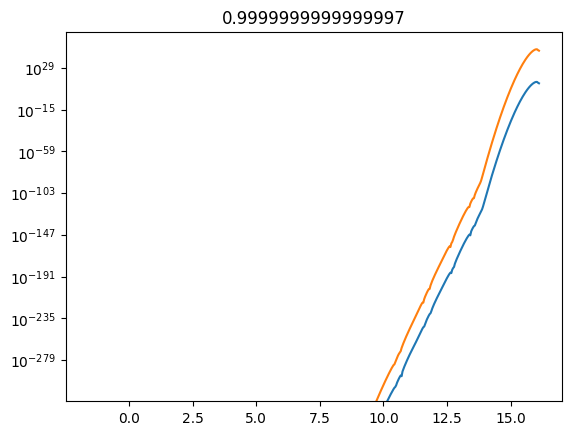

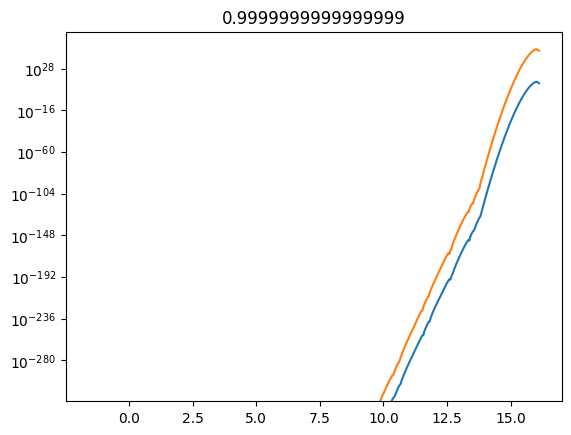

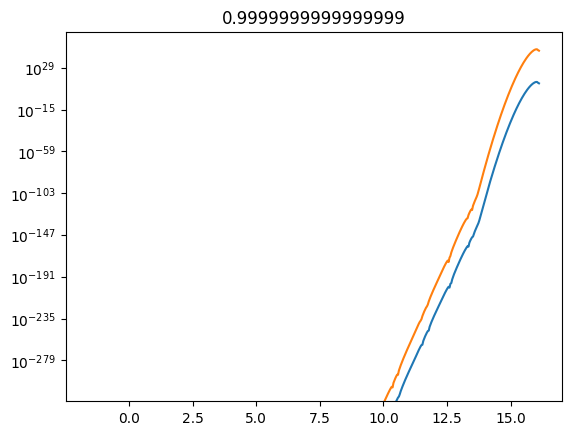

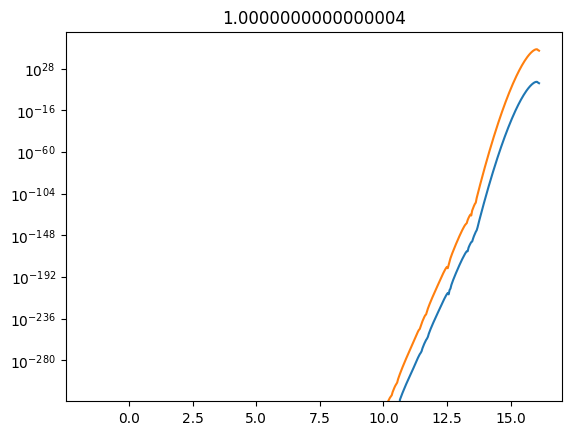

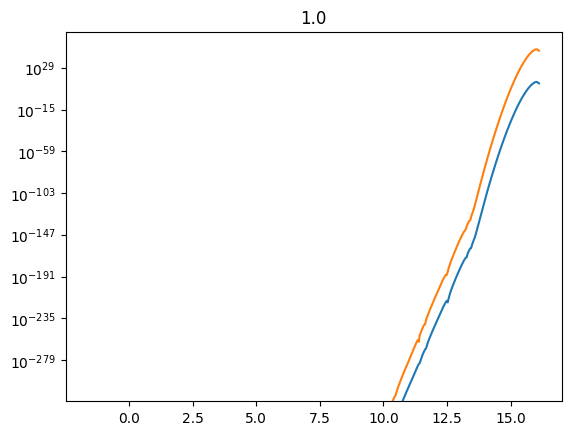

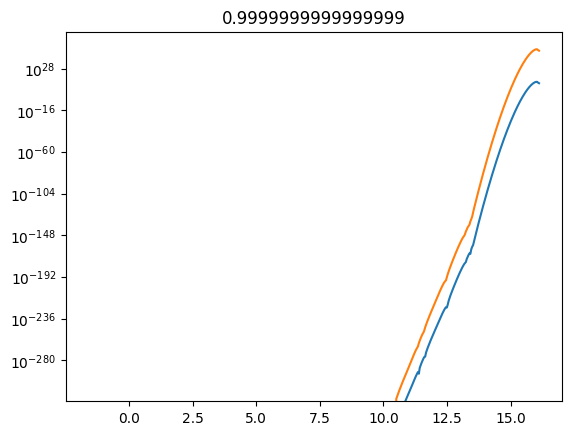

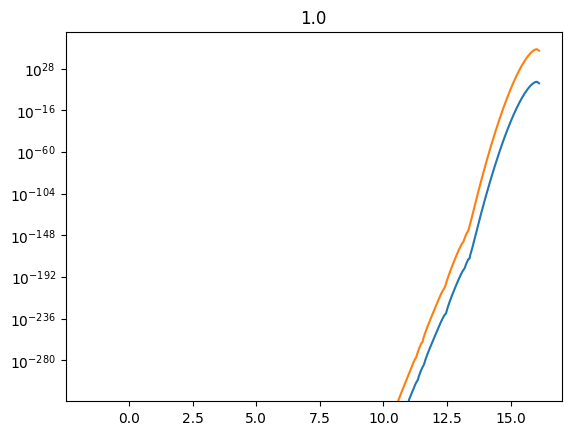

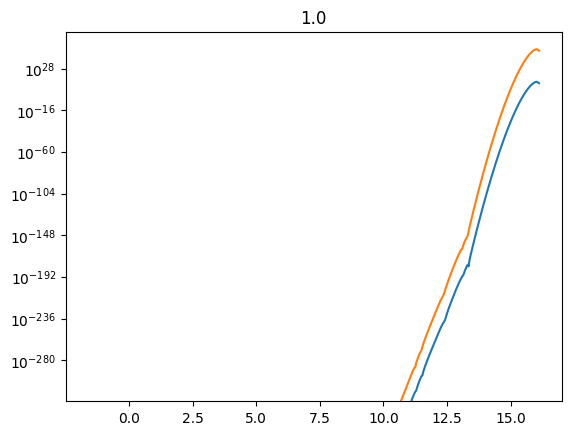

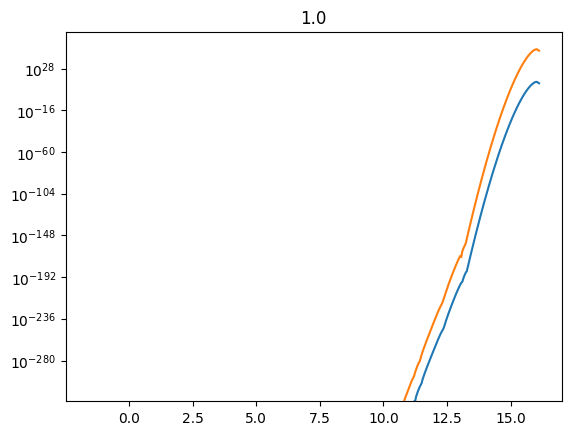

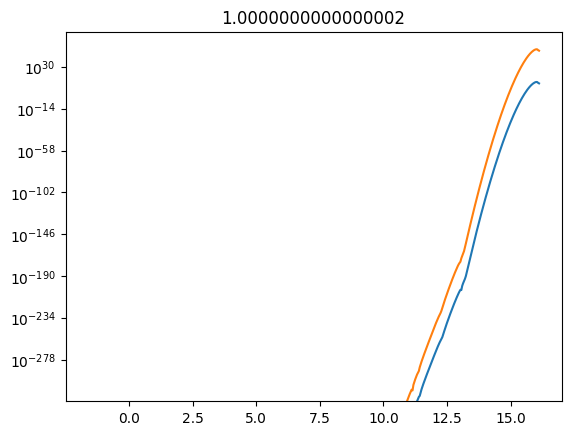

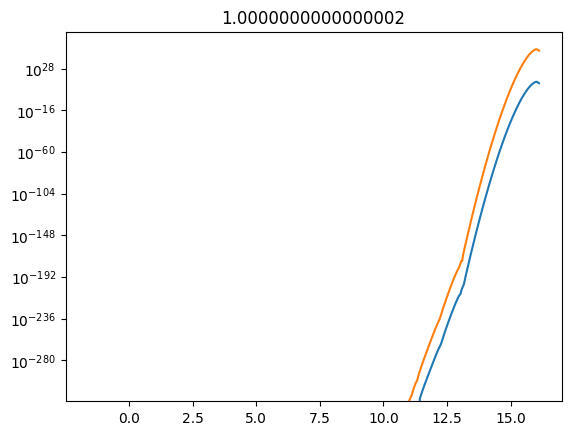

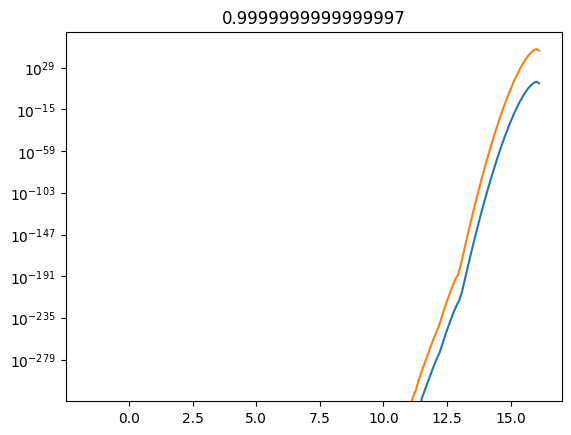

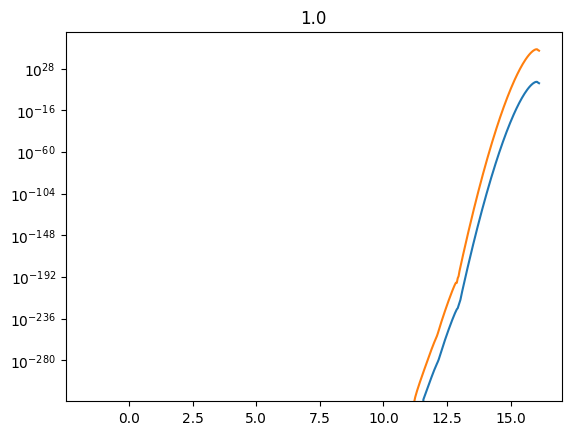

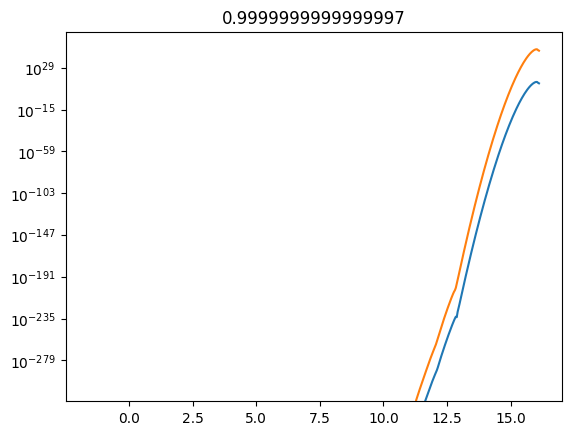

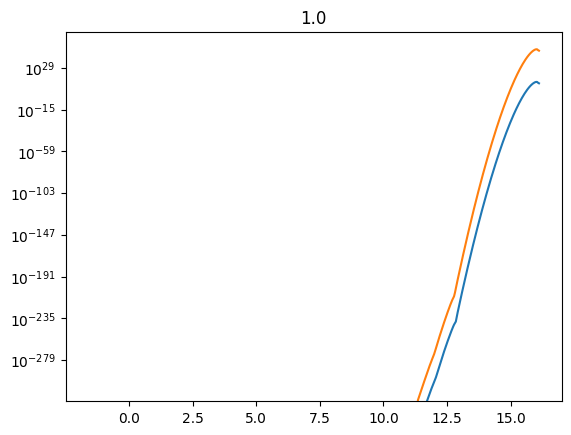

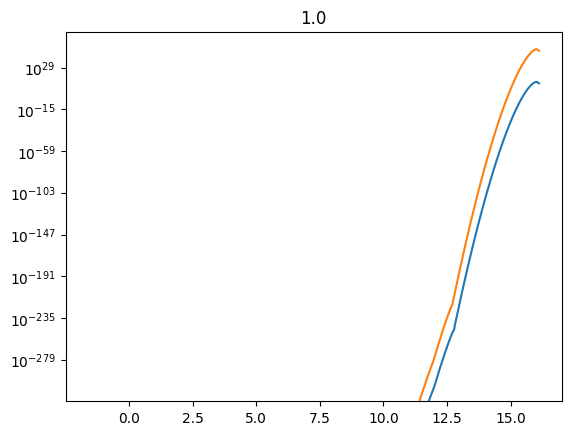

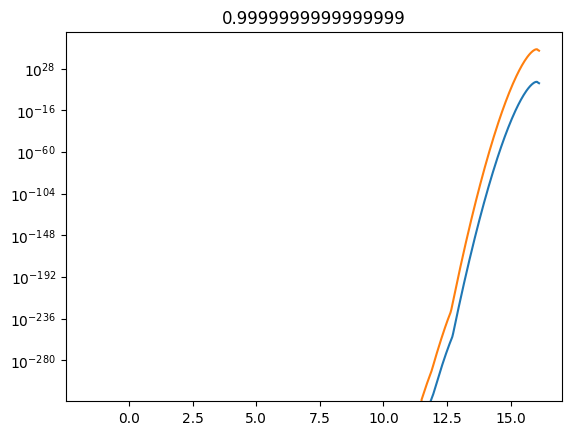

KeyboardInterrupt: 

In [162]:
iterations = 5000
step = 0.001 + 1j*0
norms = []

ground = harmonic(r)
psi = np.copy(psi0)
for i in range(0,iterations):
    
    plt.plot(y,np.abs(psi)**2)
    plt.plot(y,np.abs(Hamiltonian(psi,y))**2)
    plt.yscale("log")
    plt.title(ComputeNorm(np.copy(psi),y))
    plt.show()

    # Runge-kutta 3-th order
    k0 = -step*Hamiltonian(psi,y)
    k1 = -step*Hamiltonian(psi+k0/2,y)
    k2 = -step*Hamiltonian(psi+2*k1-k0,y)

    psi = psi + (k0 + 4*k1 + k2)/6

    # normalize psi
    psi = psi/np.sqrt(ComputeNorm(np.copy(psi),y))

    if i%100:
        norms.append(np.power(np.abs(psi-ground),2).sum())


/home/helium-rui/HeliumTools/helnev/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/helium-rui/HeliumTools/helnev/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


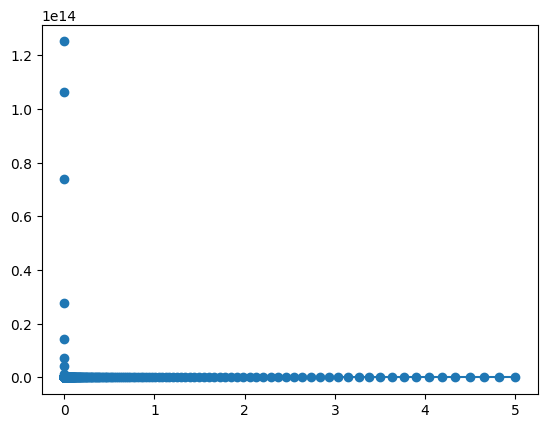

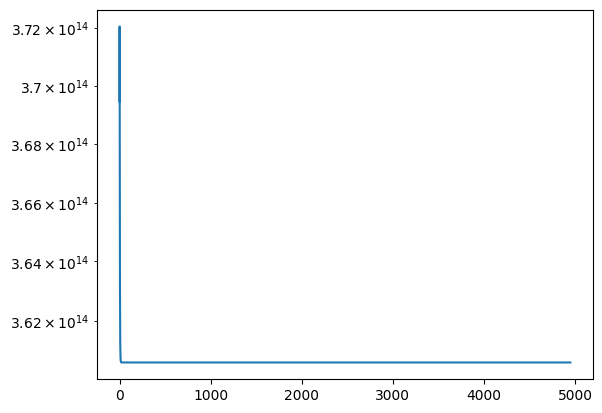

In [161]:
plt.plot(np.real(r),ground*np.conjugate(ground))
plt.scatter(np.real(r),np.real(psi*np.conjugate(psi)))
plt.show()

plt.plot(norms)
plt.yscale("log")
plt.show()

## Approach 3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import bec2DCylindrical.utils as ut
from scipy.integrate import simpson
from scipy.interpolate import make_interp_spline

In [ ]:
def potential(x):
    return 0.5*np.power(x,2)

def laplacian(func,x):
    """ Impose boundary condition on last edge """
    func[-1] = 0 + 1j*0

    """ compute first derivative """
    first = derivative_rui(func,x,1,False,9)
    # impose boundary condition in first derivative at r == 0
    first[0] = 0 + 1j*0
    
    """ compute second derivative """
    second = derivative_rui(func,x,2,False,9)

    """ compute laplacian """
    lap = second - first/x + func/np.power(x,2)

    """ extrapolate edges """
    lap = extrapolate_derivative(x,lap,9)

    return lap

def Hamiltonian(func,x):
    x = np.real(x)
    # normalize func
    func = func/np.sqrt(ComputeNorm(np.copy(func),x))
    # return kinetic propagator
    kinetic = -0.5*laplacian(func,x)*np.exp(2*x)
    # compute potential propagator
    r = np.exp(-x)
    pot = potential(r)*func
    return kinetic + pot

def ComputeNorm(func,x):
    N = -np.exp(-2*np.real(x))*func*np.conjugate(func)
    return np.real(-2*np.pi*simpson(N,np.real(x)))

In [40]:
1/0.04

25.0

In [2]:
import numpy as np
import scipy.fft as fft

In [3]:
fft.fht

<uarray multimethod 'fht'>

In [5]:
mu = 0.0                     # Order mu of Bessel function
r = np.logspace(-7, 1, 128)  # Input evaluation points
dln = np.log(r[1]/r[0])      # Step size
offset = fft.fhtoffset(dln, initial=-6*np.log(10), mu=mu)
#k = np.exp(offset)/r[::-1]   # Output evaluation points

In [6]:
np.exp(offset)

np.float64(9.383696321400027e-07)

In [9]:
np.pi/dln*(np.exp(-127*dln)-np.exp(-126*dln))

np.float64(-3.380855147100017e-08)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as special
from numpy import fft

In [22]:
def g(x,nu):

    y1 = special.gamma((nu+x+1)/2)
    y2 = special.gamma((nu-x+1)/2)

    return np.power(2,x)*y1/y2


def f(r):
    return np.exp(-np.power(r,2)/2)

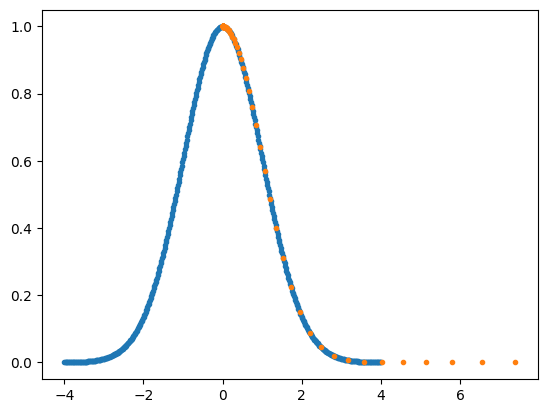

In [112]:
# define grid parameters
r0 = 1
k0 = 1
y = np.linspace(-10,2,100)
R = np.linspace(-4,4,500) 
r = r0*np.exp(y)
k = k0*np.exp(y)

# define Hankel transformation parameters
nu = 0

# plot original function
plt.plot(R,f(R),".")
plt.plot(r,f(r),".")
plt.show()

In [113]:
""" compute fft in x-space of func """
def computeFT(func,x):
    # get spacing
    dx = x[1] - x[0]
    # pad array with zeros and position position zero as the first element
    N = len(func)
    func = np.fft.ifftshift(np.pad(func, (N//2,N//2), mode='constant', constant_values = (0.0,0.0)))
    # compute fft
    FT = fft.fft(func)*dx
    # do a shift to position the zero momentum at the center
    FT = np.fft.fftshift(FT)
    # compute momentums
    freq = np.fft.fftshift(np.fft.fftfreq(FT.size, d=dx))

    return freq , FT



""" compute ifft in x-space of func """
def iFT(func,x):
    # get spacing
    dx = x[1] - x[0]
    # shidt position position zero as the first element
    func = np.fft.ifftshift(func)
    # compute fft
    FT = fft.ifft(func)*dx
    # do a shift to position the zero momentum at the center
    FT = np.fft.fftshift(FT)
    # unpad array
    N = len(func)//2
    FT = FT[N//2:N+N//2]

    # compute momentums
    freq = np.fft.fftshift(np.fft.fftfreq(FT.size, d = 2*dx))

    return freq , FT

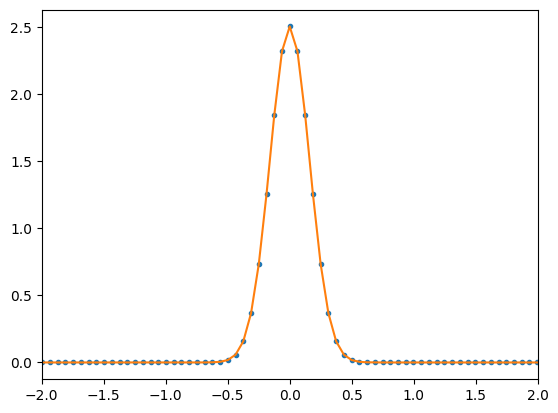

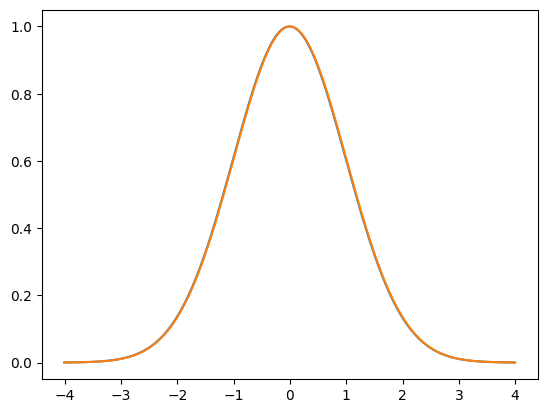

In [114]:
""" compute fft in R-space for f """
freq , FT = computeFT(f(R),R)
# plot
plt.plot(freq,np.real(FT),".")
plt.plot(freq,np.sqrt(2*np.pi)*np.exp(-2*(np.pi*freq)**2))

plt.xlim(-2,2)
plt.show()

""" compute ifft in R-space for f """
positions , func = iFT(FT,freq)

func = func/(freq[1]-freq[0])/(positions[1]-positions[0])

# plot
plt.plot(positions,np.real(func))
plt.plot(R,f(R))

plt.show()

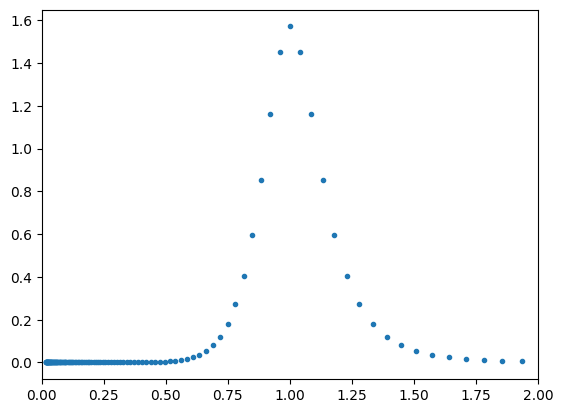

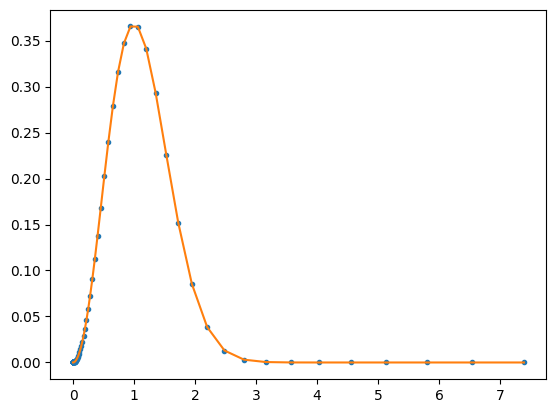

In [115]:
""" compute fft in y-space for f """
freq , FT = computeFT(f(r)*r,y)
plt.plot(np.exp(freq),np.abs(FT)**2,".")
plt.xlim(0,2)
plt.show()

""" compute ifft in y-space for f """
positions , func = iFT(FT,freq)
func = func/(freq[1]-freq[0])/(positions[1]-positions[0])
positions = positions + (y[-1]+y[0] + y[1]-y[0])/2
plt.plot(np.exp(positions),np.abs(func)**2,".")
plt.plot(np.exp(y),np.abs(f(r)*r)**2)
plt.show()


In [177]:
""" compute fft in x-space of func """
def FTLog(func,x):
    # get spacing
    dx = x[1] - x[0]
    # pad array with zeros and position position zero as the first element
    N = len(func)
    func = np.pad(func, (N//2,N//2), mode='constant', constant_values = (0.0,0.0))
    # compute fft
    FT = fft.fft(func)
    # compute momentums
    freq = np.fft.fftfreq(FT.size, d=dx)

    return freq , FT



""" compute ifft in x-space of func """
def iFTLog(func,x):
    # get spacing
    dx = x[1] - x[0]
    # compute fft
    FT = fft.ifft(func)
    # unpad array
    N = len(func)//2
    FT = FT[N//2:N+N//2]

    # compute momentums
    freq = np.fft.fftshift(np.fft.fftfreq(FT.size, d = 2*dx))

    return freq , FT


def FHT(func,y,nu,r0,k0):
    # compute fft
    r = r0*np.exp(y)
    xi , FT = FTLog(func,y)
    # compute U function
    U = g(2j*np.pi*xi,nu)
    # compute prod
    z0 = r0*k0
    prod = FT*U*np.power(z0,-2j*np.pi*xi)
    # compute ifft
    x , func = iFTLog(prod,xi)
    x = x + (y[-1]+y[0] + y[1]-y[0])/2

    return x , func/(k0*np.exp(x))

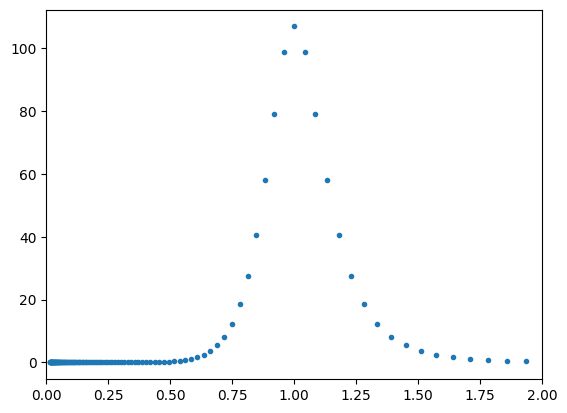

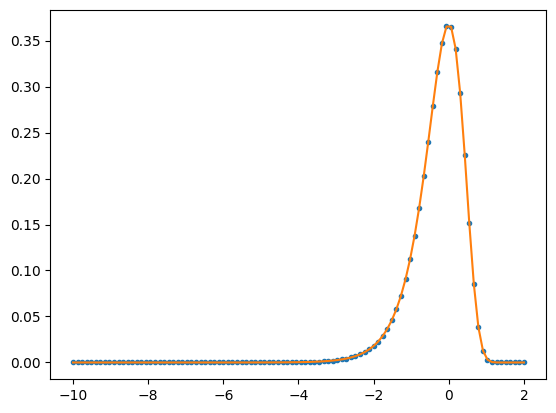

In [182]:
""" compute fft in y-space for f """
freq , FT = FTLog(f(r)*r,y)
plt.plot(np.exp(freq),np.abs(FT)**2,".")
plt.xlim(0,2)
plt.show()

""" compute ifft in y-space for f """
positions , func = iFTLog(FT,freq)
positions = positions + (y[-1]+y[0] + y[1]-y[0])/2
plt.plot(positions,np.abs(func)**2,".")
plt.plot(positions,np.abs(f(np.exp(positions))*np.exp(positions))**2)
plt.show()


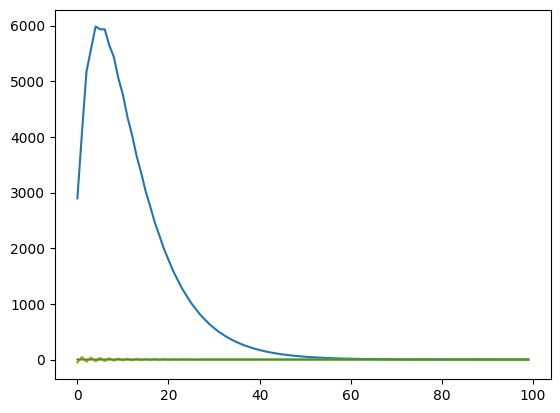

In [179]:
x , HT = FHT(f(r),y,nu,r0,k0)

k = k0*np.exp(x)
plt.plot(np.real(HT))
plt.plot(np.imag(HT))
plt.plot(f(k))
plt.show()